This notebook walks the user through the process of creating an automatic alignment pipeline, for use in the Video Analysis notebook. You will need a pair of images or videos, one from the visible and one from the ultraviolet camera. It is best to select a pair that contain a number of easily distinguishable marks, as we will need to select common points in each image to create the coarse alignment.

In [1]:
%gui tk

import v2v_nb

vis_selector = uv_selector = warp_op = None

config = v2v_nb.get_config(clear=True)
v2v_nb.ConfigBox('save_align_pipe_path', 'vis_path', 'uv_path', 'build_video_pipeline', 'out_format')

ConfigBox(children=(PathBox(children=(Label(value='Alignment Pipeline'), HBox(children=(Text(value='', continu…

We need to select a number of tie points in each image. A tie point is a pair of points, one in the visible image and one in the ultraviolet image, where the point in the picture corresponds to the same point in the physical world. The ideal tie points are precise and easily distinguishable, for example, the corners of a notecard. It is best to be as precise as possible, but exact accuracy is not needed. First, select the tie points in the visible image below.

In [2]:
vis_selector = v2v_nb.make_selectorbox('vis_path', require_alignment=False, marker_choice='cross')
display(vis_selector)

SelectorBox(children=(Image(value=b"\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02X\x00\x00\x01Q\x08\x02\x00\…

Now do it again for the ultraviolet image. Make sure to select the tie points in the same order.

In [3]:
uv_selector = v2v_nb.make_selectorbox('uv_path', require_alignment=False, marker_choice='cross')
display(uv_selector)

SelectorBox(children=(Image(value=b"\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02X\x00\x00\x01Q\x08\x02\x00\…

We will now use those tie points to calculate a coarse alignment, and display the aligned ultraviolet next to the visible image. It is **not** necessary that the alignment be exact at this stage; it just needs to be approximately correct. If it is not, restart the notebook and try again.

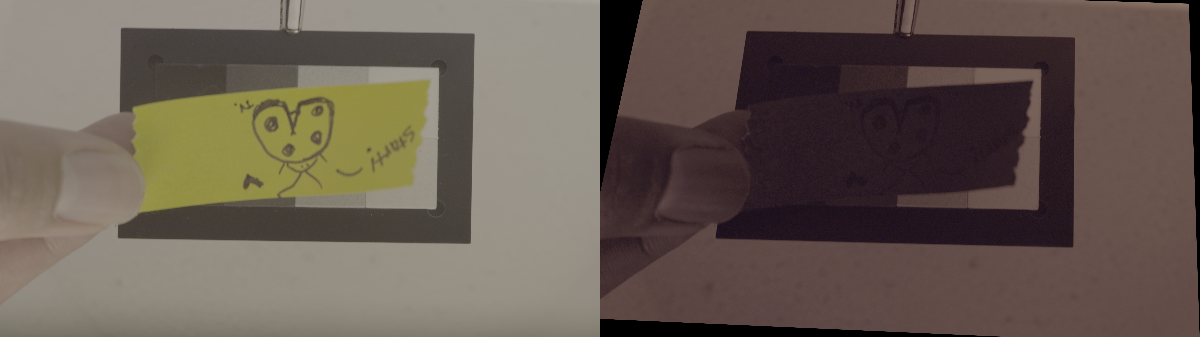

In [4]:
warp_op, display_image = v2v_nb.build_coarse_warp(vis_selector, uv_selector)
display(display_image)

We then build the alignment and save it. Once this cell is run, you can proceed to Video-Analysis.

In [5]:
v2v_nb.build_and_save_alignment_pipeline(warp_op)

Done! You can close the notebook.
